# 03. Seaborn для EDA

Seaborn используется здесь как высокоуровневый слой статистической визуализации поверх Matplotlib. Цель — быстрее исследовать распределения, категории и связи.

In [1]:
from pathlib import Path

def find_project_root() -> Path:
    """Ищет корень учебного комплекта по наличию подготовленного датасета."""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        target = candidate / "data" / "viz.csv"
        if target.exists():
            return candidate
    raise FileNotFoundError("Не найден data/viz.csv")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "viz.csv"
OUTPUT_DIR = PROJECT_ROOT / "teacher" / "out"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Data:", DATA_PATH)

Project root: <PROJECT_ROOT>\nData: <PROJECT_ROOT>/data/viz.csv\n

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)

pandas: 2.2.3
seaborn: 0.13.2


In [3]:
df = pd.read_csv(DATA_PATH)
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
print("Shape:", df.shape)
display(df.head())

Shape: (1200, 16)


,order_id,order_date,region,channel,customer_type,category,subcategory,quantity,unit_price,discount_percent,revenue,cost,profit,profit_margin,delivery_days,rating
0,RM-00278,2026-01-01,Санкт-Петербург,Партнеры,Повторный,Электроника,Аксессуары,2,25535.30,15,43410.01,32291.26,11118.75,0.2561,3,5.0
1,RM-00380,2026-01-01,Москва,Онлайн,Повторный,Электроника,Аксессуары,3,27689.11,25,62300.50,41398.18,20902.31,0.3355,3,4.9
2,RM-01198,2026-01-01,Ростов-на-Дону,Онлайн,Повторный,Электроника,Аксессуары,1,28165.80,5,26757.51,17040.27,9717.24,0.3632,6,4.4
3,RM-00014,2026-01-02,Самара,Онлайн,Новый,Электроника,Смартфоны,2,26549.60,20,42479.36,26123.07,16356.29,0.3850,7,4.4
4,RM-00053,2026-01-02,Самара,Онлайн,Повторный,Дом и кухня,Посуда,3,8456.20,10,22831.74,15530.02,7301.72,0.3198,3,4.7


## 1. Histogram + KDE

Смотрим форму распределения выручки заказа.

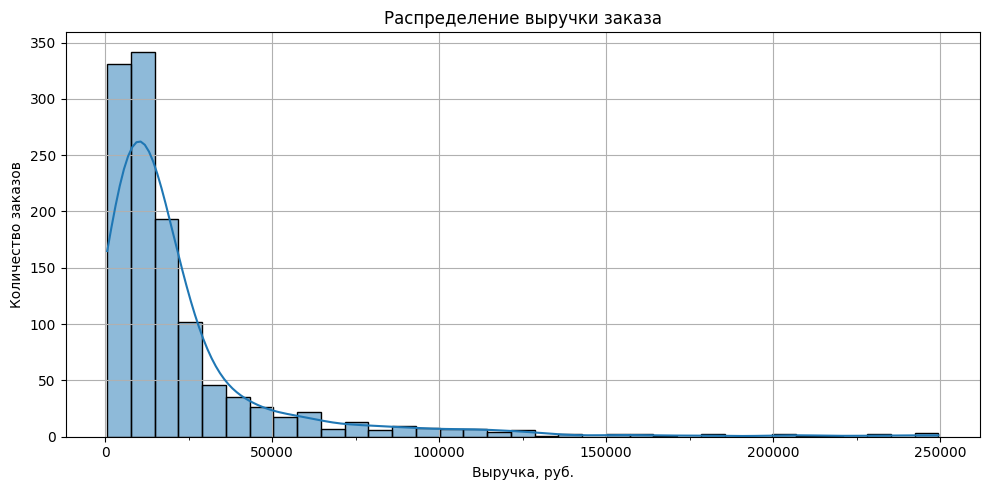

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
default_color = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]
sns.histplot(data=df, x="revenue", bins=35, kde=True, color=default_color, ax=ax)
ax.set_title("Распределение выручки заказа")
ax.set_xlabel("Выручка, руб.")
ax.set_ylabel("Количество заказов")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "10_seaborn_histplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Boxplot по типу клиента

**Вопрос:** различается ли типичный размер заказа между новыми, повторными и корпоративными клиентами?

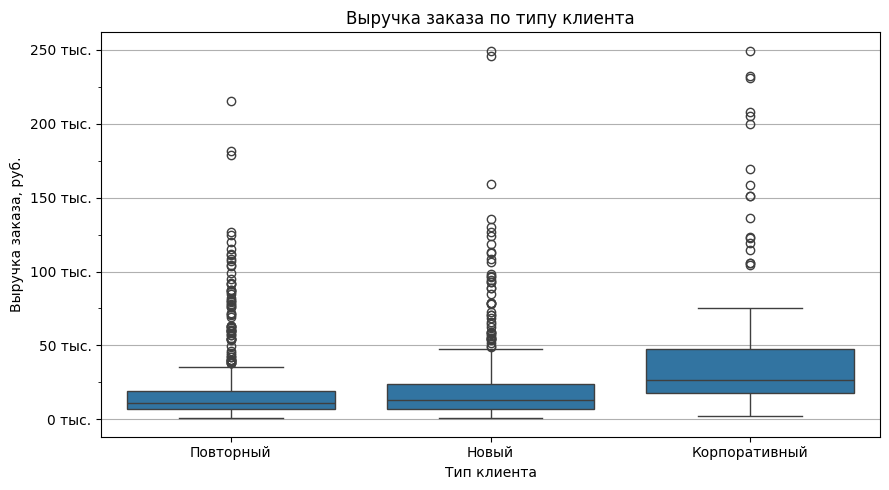

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="customer_type", y="revenue", ax=ax)
ax.set_title("Выручка заказа по типу клиента")
ax.set_xlabel("Тип клиента")
ax.set_ylabel("Выручка заказа, руб.")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:.0f} тыс."))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, axis="y", which="major")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "11_customer_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Scatter + сегментация

Цвет/категориальный слой используем только когда он отвечает на вопрос. Здесь сравниваем типы клиентов.

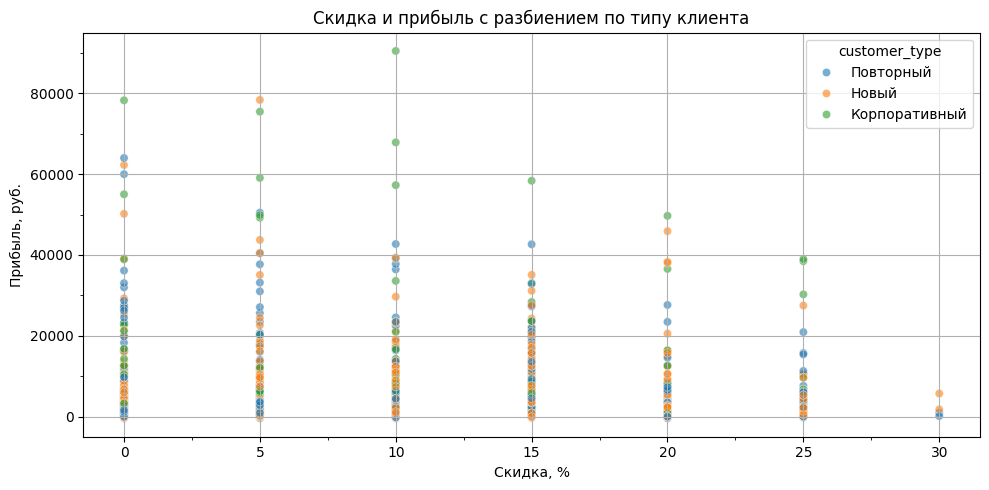

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df, x="discount_percent", y="profit", hue="customer_type", alpha=0.6, ax=ax)
ax.set_title("Скидка и прибыль с разбиением по типу клиента")
ax.set_xlabel("Скидка, %")
ax.set_ylabel("Прибыль, руб.")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "12_discount_profit_by_customer.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Матрица корреляций

Используем только числовые признаки, а затем интерпретируем конкретные пары. Heatmap не заменяет предметный анализ.

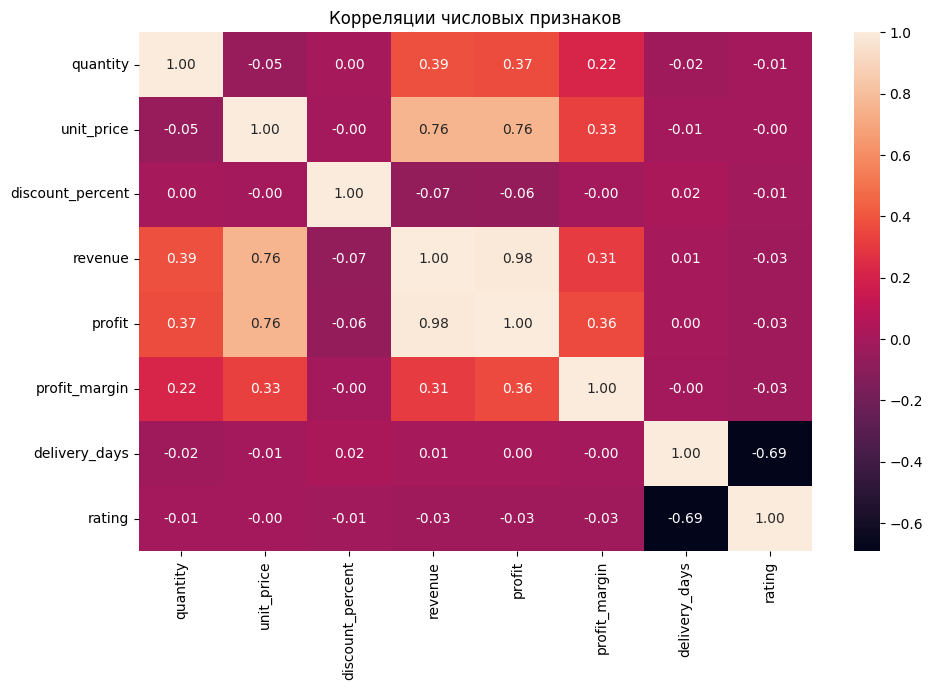

In [7]:
numeric_cols = ["quantity","unit_price","discount_percent","revenue","profit","profit_margin","delivery_days","rating"]
corr = df[numeric_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", ax=ax)
ax.set_title("Корреляции числовых признаков")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "13_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Контрольный вопрос

Выберите одну сильную/заметную связь на heatmap и сформулируйте корректный вывод **без причинного утверждения**.

## 5. Практика

Проверьте, как срок доставки связан с оценкой клиента. Выберите график сами.

Минимум:

- визуализация;
- подписи;
- деления;
- один числовой показатель связи или группового сравнения;
- вывод с ограничением.

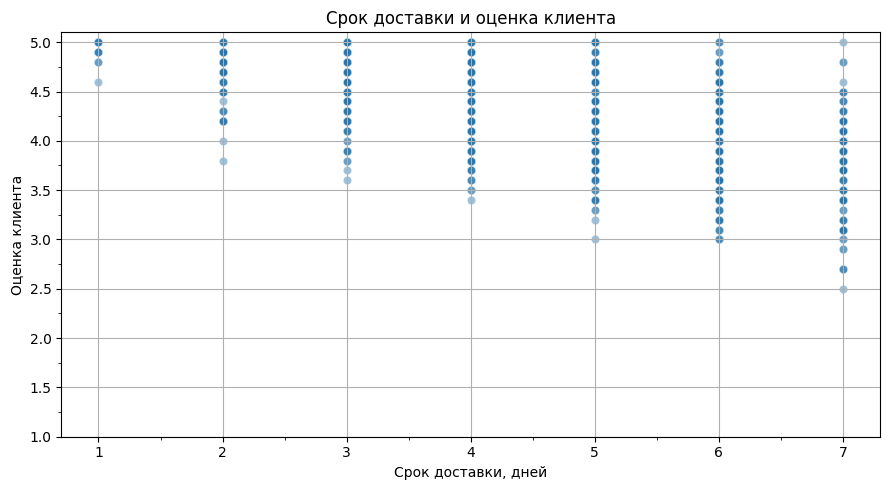

Корреляция delivery_days/rating: -0.691


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="delivery_days", y="rating", alpha=0.45, ax=ax)
ax.set_title("Срок доставки и оценка клиента")
ax.set_xlabel("Срок доставки, дней")
ax.set_ylabel("Оценка клиента")
ax.set_ylim(1, 5.1)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "14_delivery_rating_solution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Корреляция delivery_days/rating:", round(df[["delivery_days","rating"]].corr().iloc[0,1], 3))

### Эталонная интерпретация

В синтетическом наборе корреляция срока доставки и оценки равна примерно **-0.69**. Это показывает отрицательную ассоциацию: при более долгой доставке оценки в среднем ниже. Поскольку данные учебные и наблюдательные, причинный вывод делать нельзя.